# 02 · Why random splits score near 1.0

**Question.** Why does a random train/test split give near-perfect scores, and do the
leakage checks pass?

A score of 1.0 is not impossible: it means every test attack outranked every benign flow. It is a
red flag that has to be explained before it is shown.

Finding: when test flows come from the same capture as training, LightGBM scores AP 0.9908-0.9998 even after grouping similar flows together. When the test is a new day, AP falls to 0.22-0.79. The near-perfect number answers 'does it recognize this capture's attacks?', not 'can it detect new ones?'


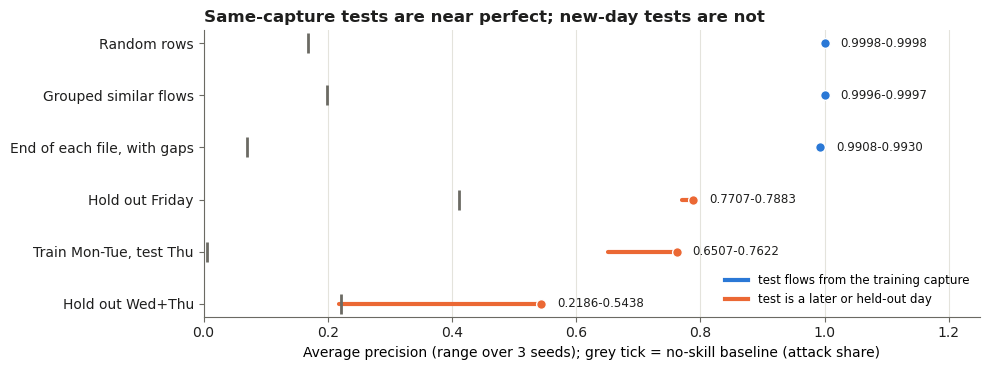

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reporting.plots import load_summary, recall_dots, recall_table, style, COLORS, NAMES, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
REPORTS = "../reports"

gen = json.load(open(f"{REPORTS}/generalization_evaluation.json"))
aud = json.load(open(f"{REPORTS}/leakage_audit.json"))
rows = []
def add(label, kind, reps):
    ap = [r["test_average_precision"] for r in reps]
    rows.append({"protocol": label, "kind": kind, "AP min": min(ap), "AP max": max(ap),
                 "prevalence": reps[0]["test_prevalence"],
                 "recall at 1% (median)": float(np.median([r["test_at_frozen_thresholds"]["0.01"]["recall"] for r in reps])),
                 "actual FPR at 1% (median)": float(np.median([r["test_at_frozen_thresholds"]["0.01"]["fpr"] for r in reps]))})
add("Random rows", "same capture", [r["candidates"]["lgbm71"] for r in gen["runs"] if r["split"] == "random_split"])
for proto, label, kind in [("grouped_quarter_octave", "Grouped similar flows", "same capture"),
                           ("purged_file_blocks", "End of each file, with gaps", "same capture"),
                           ("test_friday", "Hold out Friday", "new day"),
                           ("forward_thursday", "Train Mon-Tue, test Thu", "new day"),
                           ("test_wed_thu", "Hold out Wed+Thu", "new day")]:
    add(label, kind, [r["candidates"]["lgbm71"] for r in aud["runs"] if r["protocol"] == proto])
protocols = pd.DataFrame(rows)
same, new = protocols[protocols.kind == "same capture"], protocols[protocols.kind == "new day"]
print(f"Finding: when test flows come from the same capture as training, LightGBM scores AP "
      f"{same['AP min'].min():.4f}-{same['AP max'].max():.4f} even after grouping similar flows together. "
      f"When the test is a new day, AP falls to {new['AP min'].min():.2f}-{new['AP max'].max():.2f}. "
      f"The near-perfect number answers 'does it recognize this capture's attacks?', not 'can it detect new ones?'")

fig, ax = plt.subplots(figsize=(10, 3.8))
for i, r in protocols.iterrows():
    color = "#2a78d6" if r.kind == "same capture" else "#eb6834"
    ax.plot([r["AP min"], r["AP max"]], [i, i], color=color, linewidth=3, solid_capstyle="round")
    ax.plot(r["AP max"], i, "o", color=color, markersize=7, markeredgecolor="white")
    ax.plot(r["prevalence"], i, "|", color=MUTED, markersize=14, markeredgewidth=2)
    ax.text(r["AP max"] + 0.025, i, f"{r['AP min']:.4f}-{r['AP max']:.4f}", va="center", fontsize=8.5, color=INK)
ax.set_yticks(range(len(protocols))); ax.set_yticklabels(protocols.protocol); ax.invert_yaxis()
ax.set_xlim(0, 1.25); ax.set_xlabel("Average precision (range over 3 seeds); grey tick = no-skill baseline (attack share)")
ax.set_title("Same-capture tests are near perfect; new-day tests are not", loc="left", fontweight="bold", color=INK)
ax.plot([], [], color="#2a78d6", linewidth=3, label="test flows from the training capture")
ax.plot([], [], color="#eb6834", linewidth=3, label="test is a later or held-out day")
ax.legend(frameon=False, fontsize=8.5, loc="lower right"); style(ax); fig.tight_layout(); plt.show()

In [2]:
protocols.round(4)

,protocol,kind,AP min,AP max,prevalence,recall at 1% (median),actual FPR at 1% (median)
0,Random rows,same capture,0.9998,0.9998,0.1687,0.9999,0.0099
1,Grouped similar flows,same capture,0.9996,0.9997,0.1985,0.9999,0.0123
2,"End of each file, with gaps",same capture,0.9908,0.9930,0.0704,0.9846,0.0103
3,Hold out Friday,new day,0.7707,0.7883,0.4110,0.3373,0.0125
4,"Train Mon-Tue, test Thu",new day,0.6507,0.7622,0.0048,0.8172,0.0119
5,Hold out Wed+Thu,new day,0.2186,0.5438,0.2208,0.0099,0.0085


## The leakage gates

No number reaches the README until these hold. The table below the printout shows them for every
fold of the forward-in-time evaluation (notebooks 03-06).

| Gate | Pass rule |
| --- | --- |
| No exact twins | Report test rows whose model inputs exactly match a training row. Across days some twins are legitimate (identical benign DNS lookups, repeated flood packets); inside one capture they are leakage. |
| Feature choice inside training data | All 71 features are used; no selection step. The old 20-feature subset was picked using importance on all data, so it is not used here. |
| Shuffled-label control | A model trained on shuffled labels scores near the prevalence. |
| Shortcut check | Flag any fold where one feature alone comes within 0.05 average precision of the full model. |
| Thresholds from validation only | No threshold or model choice uses test labels; the actual test false positive rate is reported. |

In [3]:
legacy = aud["legacy_audit"]["random_split_seed_42"]
shuffle = aud["shuffled_training_labels"]
summary = load_summary()
fold_gates = pd.DataFrame({f: {"exact twins (share of test rows)": g["gates"]["exact_twin_test_fraction"]["max"],
                               "exact twins that are attacks": g["gates"]["exact_twin_attack_rows"]["max"],
                               "shuffled-label AP (max)": g["gates"]["shuffled_label_ap"]["max"],
                               "prevalence": g["prevalence"],
                               "best single feature AP (max)": g["gates"]["best_single_feature_ap"]["max"],
                               "LightGBM AP (median)": (g["detectors"]["lgbm"]["average_precision"]["median"]
                                                         if "lgbm" in g["detectors"] else None)}
                           for f, g in summary["folds"].items()}).T
print(f"Legacy random split: {legacy['exact_input_overlap_n']:,} test rows had an exact input twin in training "
      f"({legacy['exact_input_overlap_fraction']:.2%}); {legacy['attack_exact_overlap_n']} were attacks.")
print(f"Shuffled-label control (grouped split): AP {shuffle['test_average_precision']:.4f} vs prevalence {shuffle['test_prevalence']:.4f}.")
fold_gates.round(4)

Legacy random split: 1,854 test rows had an exact input twin in training (0.37%); 47 were attacks.
Shuffled-label control (grouped split): AP 0.2065 vs prevalence 0.1985.


,exact twins (share of test rows),exact twins that are attacks,shuffled-label AP (max),prevalence,best single feature AP (max),LightGBM AP (median)
2017_A,0.0369,294.0,0.3641,0.3641,0.7783,NaN
2017_B,0.0652,0.0,0.0124,0.0048,0.1031,0.6633
2017_C,0.0483,0.0,0.5819,0.4110,0.7436,0.7730
2017_to_2018,0.0032,1513.0,0.2810,0.1702,0.4267,0.6710
2018_new_family_bot,0.0329,0.0,0.6451,0.2742,0.7074,0.6787
2018_new_tool_ddos,0.0000,0.0,0.7189,0.6546,0.9990,0.8665
2018_new_tool_dos,0.2164,139884.0,0.8513,0.5747,0.9995,1.0000
2018_same_attack_infiltration,0.2177,19884.0,0.2801,0.2831,0.3894,0.3106
2018_same_attack_web,0.1551,30.0,0.0268,0.0005,0.1632,0.6905


## Interpretation

The near-perfect score is mostly not a code bug. Exact input twins between the old random split's
train and test sets were few (see the printout), the shuffled-label control sits at chance, and
grouping similar flows so they cannot straddle the split still leaves the score near 1.0.

The explanation is that the question is easy. Inside one lab capture, scripted attacks from a few
attacker machines are trivially separable from benign traffic. A random split asks "does the model
recognize attacks it has already seen, from the same capture?" That is a sanity check, not a
result. The forward-in-time notebooks (03-06) ask the question that matters for an intrusion
detector: can it flag the attacks of a day it has not seen?

## Limits

- Grouping similar flows uses coarse bins of 20 features; it is a proxy, not real session IDs.
- The random-row result uses the deduplicated training copy (`generalization_evaluation.json`);
  the other rows use the raw-derived population (`leakage_audit.json`).
- All of these captures have been looked at before, so none is a fresh, untouched test.